## This notebook evaluates a given model.

In [ ]:
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

from utils.models import CustomChessCNN_v3
from utils.dataset import get_test_loader
from tqdm import tqdm

#### Load all paths.

In [2]:
# Load config.
config_path = "../config.json"
with open(config_path, "r") as f:
    config = json.load(f)

# The model that is evaluated.
MODEL = "finetuned"  # chessred, unity, finetuned

# The test dataset the model is evaluated on.
DATASET_ORIGIN = "finetuned"  # chessred, unity, finetuned

model_weights_path = config[f"{MODEL}_model_path"]
dataset_path = config[f"{DATASET_ORIGIN}_test_pkl"]
config["test_pickle_path"] = dataset_path

test_loader = get_test_loader(config, batch_size=32)

Pre-computing FEN rotations (TEST)...
Done.
Total images: 1170


#### Load the model.

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model = CustomChessCNN_v3().to(DEVICE)
checkpoint = torch.load(model_weights_path, map_location=DEVICE)

if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    sd = checkpoint["state_dict"]
else:
    sd = checkpoint

sd = {k.replace("module.", ""): v for k, v in sd.items()}
model.load_state_dict(sd, strict=True)
model.eval()

lr = 1e-4
weight_decay = 1e-5
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

print("Model and optimizer loaded.")

Model and optimizer loaded.


C:\Users\olden\AppData\Local\Temp\ipykernel_1408\806472777.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_weights_path, map_location=DEVIC

In [4]:
# PRINT STATMENTS - MODEL INSPECTION

# Print model's state_dict
print("Model's state_dict:")
for param_tensor in model.state_dict():
    print(param_tensor, "\t", model.state_dict()[param_tensor].size())

# Print optimizer's state_dict
print("Optimizer's state_dict:")
for var_name in optimizer.state_dict():
    print(var_name, "\t", optimizer.state_dict()[var_name])

Model's state_dict:
stem.0.weight 	 torch.Size([64, 3, 7, 7])
stem.1.weight 	 torch.Size([64])
stem.1.bias 	 torch.Size([64])
stem.1.running_mean 	 torch.Size([64])
stem.1.running_var 	 torch.Size([64])
stem.1.num_batches_tracked 	 torch.Size([])
layer1.0.bn1.weight 	 torch.Size([64])
layer1.0.bn1.bias 	 torch.Size([64])
layer1.0.bn1.running_mean 	 torch.Size([64])
layer1.0.bn1.running_var 	 torch.Size([64])
layer1.0.bn1.num_batches_tracked 	 torch.Size([])
layer1.0.conv1.weight 	 torch.Size([128, 64, 3, 3])
layer1.0.bn2.weight 	 torch.Size([128])
layer1.0.bn2.bias 	 torch.Size([128])
layer1.0.bn2.running_mean 	 torch.Size([128])
layer1.0.bn2.running_var 	 torch.Size([128])
layer1.0.bn2.num_batches_tracked 	 torch.Size([])
layer1.0.conv2.weight 	 torch.Size([128, 128, 3, 3])
layer1.0.downsample.weight 	 torch.Size([128, 64, 1, 1])
layer1.1.bn1.weight 	 torch.Size([128])
layer1.1.bn1.bias 	 torch.Size([128])
layer1.1.bn1.running_mean 	 torch.Size([128])
layer1.1.bn1.running_var 	 torch.

#### TEST RUN - GET THE PREDICTIONS

In [5]:
all_preds = []
all_labels = []
all_paths = []

model.eval()
with torch.no_grad():
    for images, labels, paths in tqdm(test_loader):
        # FIX: Move images to the same device as the model
        images = images.to(DEVICE)
        logits = model(images)  # Shape: (Batch, 64, 13)

        # For each of the 64 squares, get the best performing class
        _, predicted = torch.max(logits, dim=2)
        all_preds.extend(predicted.cpu().numpy())

        # FIX: Safely convert the tuple of 4 rotated label tensors to numpy
        batch_labels_np = np.array(
            [[rot.cpu().numpy() for rot in rot_list] for rot_list in labels]
        )
        all_labels.extend(batch_labels_np)

        all_paths.extend(paths)

# Convert to numpy arrays
all_preds = np.array(all_preds)  # Shape: (Total_Images, 64)
all_labels = np.array(all_labels)  # Shape: (Total_Images, 4, 64)

print(f"Evaluation complete. Processed {len(all_preds)} images.")

  0%|          | 0/37 [00:00<?, ?it/s]

100%|██████████| 37/37 [03:20<00:00,  5.43s/it]

Evaluation complete. Processed 1170 images.


In [6]:
results = {}


# Important to check all rotations!
expanded_preds = np.expand_dims(all_preds, axis=1)  # Shape: (Total_Images, 1, 64)
matches = all_labels == expanded_preds  # Shape: (Total_Images, 4, 64)
correct_suqares_per_rotation = matches.sum(axis=2)  # Shape: (Total_Images, 4)
best_rotation_matches_counts = correct_suqares_per_rotation.max(
    axis=1
)  # Shape: (Total_Images,)

# Calculate final metrics
per_square_acc = best_rotation_matches_counts.sum() / (
    len(best_rotation_matches_counts) * 64
)
full_board_acc = (best_rotation_matches_counts == 64).mean()
errors_per_board = 64 - best_rotation_matches_counts

results["test"] = {
    "N": int(all_labels.shape[0]),
    "per_square_acc": float(per_square_acc),
    "avg_board_acc": float((best_rotation_matches_counts / 64).mean()),
    "full_board_acc": float(full_board_acc),
    "errors_per_board": errors_per_board,
}

print("--- EVALUATION RESULTS ---")
for s, m in results.items():
    print(
        s,
        {
            k: (round(v, 4) if isinstance(v, float) else v if k == "N" else "...")
            for k, v in m.items()
        },
    )

--- EVALUATION RESULTS ---
test {'N': 1170, 'per_square_acc': 0.9726, 'avg_board_acc': 0.9726, 'full_board_acc': 0.6504, 'errors_per_board': '...'}


test: 761 / 1170 boards fully correct


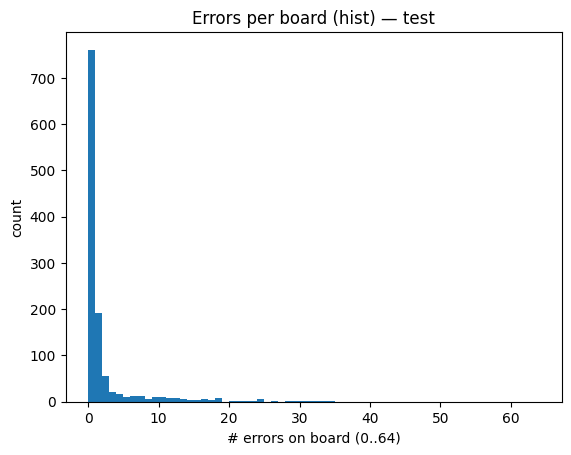

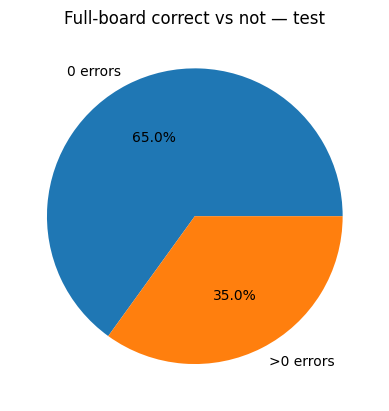

In [7]:
for split, m in results.items():
    n_full = int(
        (64 - m["errors_per_board"]).astype(int).sum() == 64
    )  # placeholder line
    # Correct calculation:
    n_full = int((m["errors_per_board"] == 0).sum())
    print(f"{split}: {n_full} / {m['N']} boards fully correct")

    plt.figure()
    plt.hist(m["errors_per_board"], bins=range(0, 65))
    plt.title(f"Errors per board (hist) — {split}")
    plt.xlabel("# errors on board (0..64)")
    plt.ylabel("count")
    plt.show()

    zero = int((m["errors_per_board"] == 0).sum())
    nonzero = int((m["errors_per_board"] > 0).sum())
    plt.figure()
    plt.pie([zero, nonzero], labels=["0 errors", ">0 errors"], autopct="%1.1f%%")
    plt.title(f"Full-board correct vs not — {split}")
    plt.show()

In [8]:
def _ece_reliability(max_probs, correct, n_bins=15):
    """
    max_probs: (N,) float in [0,1]; correct: (N,) bool
    Returns: ece, (bin_conf, bin_acc, bin_count)
    """
    max_probs = np.asarray(max_probs)
    correct = np.asarray(correct).astype(np.float32)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    bin_conf = []
    bin_acc = []
    bin_count = []
    N = len(max_probs)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (
            (max_probs > lo) & (max_probs <= hi)
            if i > 0
            else (max_probs >= lo) & (max_probs <= hi)
        )
        cnt = mask.sum()
        if cnt == 0:
            bin_conf.append(np.nan)
            bin_acc.append(np.nan)
            bin_count.append(0)
            continue
        conf = max_probs[mask].mean()
        acc = correct[mask].mean()
        ece += (cnt / N) * abs(acc - conf)
        bin_conf.append(conf)
        bin_acc.append(acc)
        bin_count.append(int(cnt))
    return float(ece), np.array(bin_conf), np.array(bin_acc), np.array(bin_count)

In [9]:
DEFAULT_ID_TO_PIECE = {
    0: "P",
    1: "R",
    2: "N",
    3: "B",
    4: "Q",
    5: "K",
    6: "p",
    7: "r",
    8: "n",
    9: "b",
    10: "q",
    11: "k",
    12: "1",
}


def _basic_legality_checks(pred_labels_64, id_to_piece=DEFAULT_ID_TO_PIECE):
    """
    Very light legality: 1 white king, 1 black king; no pawns on ranks 1/8; <=8 pawns/side.
    pred_labels_64: (64,) int tensor or array
    """
    arr = np.asarray(pred_labels_64, dtype=int)
    pieces = [id_to_piece[int(v)] for v in arr]
    # counts
    wK = sum(p == "K" for p in pieces)
    bK = sum(p == "k" for p in pieces)
    wP = sum(p == "P" for p in pieces)
    bP = sum(p == "p" for p in pieces)
    if wK != 1 or bK != 1:
        return False
    # pawn rank rule (ranks from top -> bottom in your labeling)
    top_rank = pieces[:8]
    bottom_rank = pieces[-8:]
    if any(p == "P" for p in top_rank) or any(p == "P" for p in bottom_rank):
        return False
    if any(p == "p" for p in top_rank) or any(p == "p" for p in bottom_rank):
        return False
    if wP > 8 or bP > 8:
        return False
    return True


def _confusion_and_prf1(gt, pr, num_classes=13):
    """
    gt, pr: 1D int arrays of same length (over all squares)
    Returns: conf_mat (C,C), per-class precision/recall/f1, support
    """
    gt = np.asarray(gt, dtype=int)
    pr = np.asarray(pr, dtype=int)
    conf = np.zeros((num_classes, num_classes), dtype=np.int64)
    for g, p in zip(gt, pr):
        conf[g, p] += 1

    # per-class metrics
    eps = 1e-12
    tp = np.diag(conf)
    fp = conf.sum(axis=0) - tp
    fn = conf.sum(axis=1) - tp
    prec = tp / np.maximum(tp + fp, eps)
    rec = tp / np.maximum(tp + fn, eps)
    f1 = 2 * prec * rec / np.maximum(prec + rec, eps)
    support = conf.sum(axis=1)
    return conf, prec, rec, f1, support


def evaluate_plus(
    model,
    dataloader,
    device,
    empty_class_idx=12,
    id_to_piece=DEFAULT_ID_TO_PIECE,
    compute_plots=True,
    title_prefix="Eval",
):
    """
    Rotation-invariant evaluation with rich metrics:
      - exact-board accuracy, error histogram + CDF, mean/median hamming
      - square acc (all / non-empty), top-2 acc
      - per-class precision/recall/F1, confusion matrix
      - calibration (ECE + reliability curve)
      - 8x8 correctness heatmap (avg over dataset), light/dark split
      - legality pass rate on predicted boards
      - rotation choice distribution (0°,90°,180°,270°)
    Returns: dict of metrics, plus (optionally) plots.
    """
    model.eval()
    total_loss = 0.0
    all_gt = []
    all_pr = []
    all_pr_top2_hits = []
    all_maxprob = []
    all_correct_flags = []

    board_errors = []
    rotation_picks = []  # which rotation idx chosen per board
    per_board_legality = []

    # 8x8 correctness heatmap sums
    heat_sum = np.zeros((8, 8), dtype=np.float64)
    heat_cnt = 0

    with torch.no_grad():
        pbar = tqdm(dataloader, desc="evaluate_plus", leave=False)
        for batch in pbar:
            # dataloader returns (images, label_rotations) OR (images, label_rotations, paths)
            if len(batch) == 2:
                images, label_rotations = batch
            else:
                images, label_rotations, _ = batch

            images = images.to(device)
            label_rotations = [
                [lbl.to(device) for lbl in rots] for rots in label_rotations
            ]

            outputs = model(images)  # (B, 64, 13)
            # softmax for probs
            probs = F.softmax(outputs, dim=2)
            max_prob, pred = probs.max(dim=2)  # (B,64)

            # top-2
            top2 = probs.topk(k=2, dim=2).indices  # (B,64,2)

            # choose best rotation per sample using CE loss
            B = outputs.size(0)
            matched_labels = []
            chosen_rot_idx = []
            losses = []
            for i in range(B):
                lossi = [F.cross_entropy(outputs[i], lbl) for lbl in label_rotations[i]]
                li = torch.stack(lossi)
                min_idx = int(torch.argmin(li).item())
                chosen_rot_idx.append(min_idx)
                losses.append(float(lossi[min_idx].item()))
                matched_labels.append(label_rotations[i][min_idx])

            total_loss += np.mean(losses)
            rotation_picks.extend(chosen_rot_idx)

            matched_labels = torch.stack(matched_labels)  # (B,64)
            # accumulate metrics
            gt_np = matched_labels.detach().cpu().numpy().astype(int)
            pr_np = pred.detach().cpu().numpy().astype(int)
            maxp_np = max_prob.detach().cpu().numpy()

            # per-square correctness
            correct_np = gt_np == pr_np

            # top-2 hits mask
            top2_np = top2.detach().cpu().numpy()
            pr_top2_hit = np.any(top2_np == gt_np[..., None], axis=2)

            # flatten accumulators
            all_gt.append(gt_np.reshape(-1))
            all_pr.append(pr_np.reshape(-1))
            all_pr_top2_hits.append(pr_top2_hit.reshape(-1))
            all_maxprob.append(maxp_np.reshape(-1))
            all_correct_flags.append(correct_np.reshape(-1))

            # board-level
            board_err = (gt_np != pr_np).sum(axis=1)  # per board hamming
            board_errors.extend(board_err.tolist())

            # legality per board
            for i in range(B):
                per_board_legality.append(
                    _basic_legality_checks(pr_np[i], id_to_piece=id_to_piece)
                )

            # heatmap accum
            for i in range(B):
                hm = correct_np[i].reshape(8, 8).astype(np.float32)
                heat_sum += hm
                heat_cnt += 1

    # concat everything
    all_gt = np.concatenate(all_gt, axis=0)
    all_pr = np.concatenate(all_pr, axis=0)
    all_pr_top2_hits = np.concatenate(all_pr_top2_hits, axis=0)
    all_maxprob = np.concatenate(all_maxprob, axis=0)
    all_correct_flags = np.concatenate(all_correct_flags, axis=0)

    # loss average
    avg_loss = total_loss / max(1, len(dataloader))

    # square-level acc
    acc_all = (all_gt == all_pr).mean()
    non_empty_mask = all_gt != empty_class_idx
    acc_non_empty = (
        (all_gt[non_empty_mask] == all_pr[non_empty_mask]).mean()
        if non_empty_mask.any()
        else float("nan")
    )

    # top-2 acc
    top2_all = all_pr_top2_hits.mean()
    top2_non_empty = (
        all_pr_top2_hits[non_empty_mask].mean()
        if non_empty_mask.any()
        else float("nan")
    )

    # confusion + PRF1 (all classes)
    conf, prec, rec, f1, support = _confusion_and_prf1(all_gt, all_pr, num_classes=13)

    # exclude empty for macro over pieces
    piece_classes = [i for i in range(13) if i != empty_class_idx]
    macro_f1_pieces = np.nanmean(f1[piece_classes])
    macro_prec_pieces = np.nanmean(prec[piece_classes])
    macro_rec_pieces = np.nanmean(rec[piece_classes])

    # board-level stats
    board_errors = np.array(board_errors)
    exact_board_acc = np.mean(board_errors == 0)
    mean_hamming = float(board_errors.mean())
    median_hamming = float(np.median(board_errors))
    q25 = float(np.percentile(board_errors, 25))
    q75 = float(np.percentile(board_errors, 75))

    # CDF up to, say, 10 errors for presentation
    cdf_k = list(range(0, 11))
    cdf_vals = [float(np.mean(board_errors <= k)) for k in cdf_k]

    # calibration (ECE)
    ece, bin_conf, bin_acc, bin_count = _ece_reliability(
        all_maxprob, all_correct_flags, n_bins=15
    )

    # heatmaps
    heat_avg = heat_sum / max(1, heat_cnt)  # (8,8), fraction correct per square
    # light/dark split: a1 is dark; pattern alternates. Let's assume top-left (row 0, col 0) corresponds to a8 (dark).
    light_mask = np.fromfunction(lambda r, c: (r + c) % 2 == 1, (8, 8))  # light squares
    dark_mask = ~light_mask
    acc_light = float(heat_avg[light_mask].mean())
    acc_dark = float(heat_avg[dark_mask].mean())

    # legality rate
    legality_rate = float(np.mean(per_board_legality))

    # rotation distribution
    rotation_picks = np.array(rotation_picks)
    rot_hist = {
        0: int(np.sum(rotation_picks == 0)),
        1: int(np.sum(rotation_picks == 1)),
        2: int(np.sum(rotation_picks == 2)),
        3: int(np.sum(rotation_picks == 3)),
    }
    rot_dist = {k: v / len(rotation_picks) for k, v in rot_hist.items()}

    # --- package results ---
    results = {
        "avg_loss": float(avg_loss),
        "square_acc_all": float(acc_all),
        "square_acc_non_empty": float(acc_non_empty),
        "top2_acc_all": float(top2_all),
        "top2_acc_non_empty": float(top2_non_empty),
        "confusion_matrix": conf,  # np.array (13,13)
        "per_class_precision": prec,  # np.array (13,)
        "per_class_recall": rec,  # np.array (13,)
        "per_class_f1": f1,  # np.array (13,)
        "per_class_support": support,  # np.array (13,)
        "macro_prec_pieces": float(macro_prec_pieces),
        "macro_rec_pieces": float(macro_rec_pieces),
        "macro_f1_pieces": float(macro_f1_pieces),
        "exact_board_acc": float(exact_board_acc),
        "board_error_hist": {
            int(k): int(v) for k, v in zip(*np.unique(board_errors, return_counts=True))
        },
        "board_error_mean": mean_hamming,
        "board_error_median": median_hamming,
        "board_error_q25": q25,
        "board_error_q75": q75,
        "board_error_cdf_k": cdf_k,
        "board_error_cdf_vals": cdf_vals,
        "ece": float(ece),
        "reliability_bin_conf": bin_conf,
        "reliability_bin_acc": bin_acc,
        "reliability_bin_count": bin_count,
        "heatmap_8x8": heat_avg,  # np.array (8,8), fraction correct
        "acc_light_squares": acc_light,
        "acc_dark_squares": acc_dark,
        "legality_rate": legality_rate,
        "rotation_hist": rot_hist,
        "rotation_dist": rot_dist,
    }

    if compute_plots:
        # 1) Board error histogram (clipped for readability)
        be = np.clip(board_errors, 0, 15)
        plt.figure(figsize=(6, 4))
        plt.hist(be, bins=np.arange(17) - 0.5, rwidth=0.9)
        plt.title(f"{title_prefix}: Board Errors (clipped at 15)")
        plt.xlabel("# wrong squares")
        plt.ylabel("count")
        plt.show()

        # 2) CDF
        plt.figure(figsize=(6, 4))
        plt.plot(cdf_k, cdf_vals, marker="o")
        plt.title(f"{title_prefix}: CDF of Board Errors")
        plt.xlabel("≤ errors")
        plt.ylabel("fraction of boards")
        plt.grid(True, alpha=0.3)
        plt.show()

        # 3) Confusion matrix (small, readable)
        plt.figure(figsize=(7, 6))
        plt.imshow(conf, interpolation="nearest")
        plt.title(f"{title_prefix}: Confusion Matrix (13x13)")
        plt.xlabel("Predicted")
        plt.ylabel("Ground Truth")
        plt.colorbar()
        plt.tight_layout()
        plt.show()

        # 4) Reliability curve
        ok = ~np.isnan(bin_conf) & ~np.isnan(bin_acc)
        plt.figure(figsize=(6, 4))
        plt.plot(bin_conf[ok], bin_acc[ok], marker="o", label="empirical")
        plt.plot([0, 1], [0, 1], linestyle="--", label="ideal")
        sizes = bin_count[ok]
        plt.title(f"{title_prefix}: Reliability (ECE={ece:.3f})")
        plt.xlabel("confidence")
        plt.ylabel("accuracy")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        # 5) 8x8 heatmap
        plt.figure(figsize=(5, 5))
        plt.imshow(heat_avg, vmin=0, vmax=1)
        plt.title(f"{title_prefix}: Square Accuracy Heatmap")
        plt.colorbar(label="fraction correct")
        plt.xticks(range(8))
        plt.yticks(range(8))
        plt.tight_layout()
        plt.show()

        # 6) Rotation histogram
        plt.figure(figsize=(5, 3))
        xs = [0, 1, 2, 3]
        vals = [rot_hist[k] for k in xs]
        plt.bar(xs, vals)
        plt.xticks(xs, ["0°", "90°", "180°", "270°"])
        plt.title(f"{title_prefix}: Chosen Rotation Counts")
        plt.tight_layout()
        plt.show()

    return results

evaluate_plus:   0%|          | 0/37 [00:00<?, ?it/s]

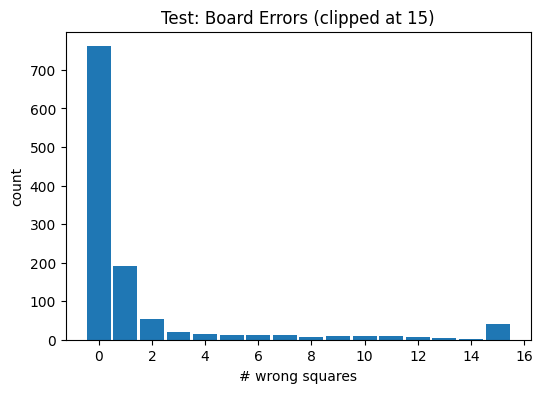

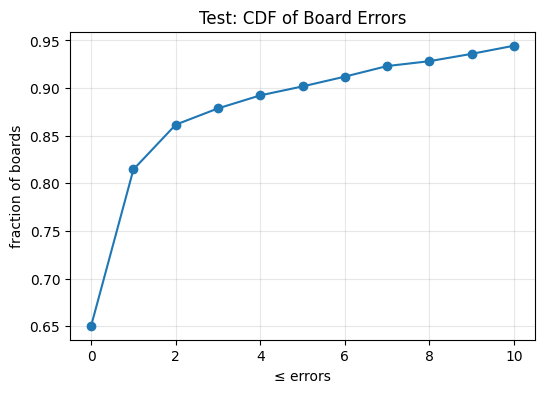

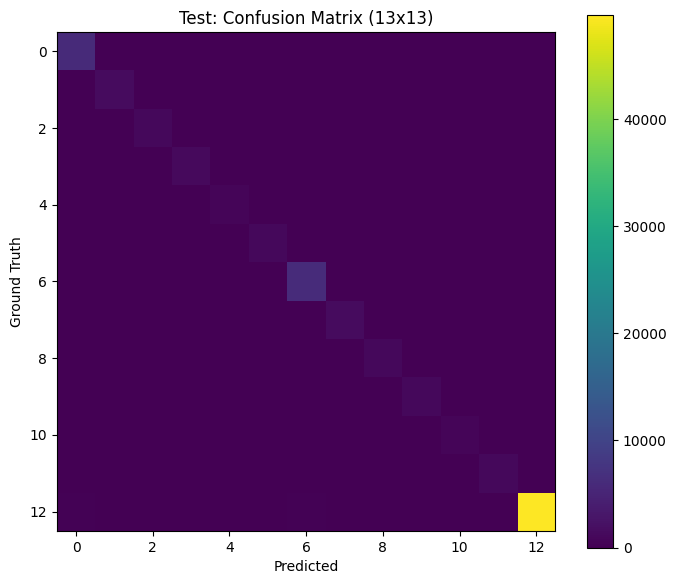

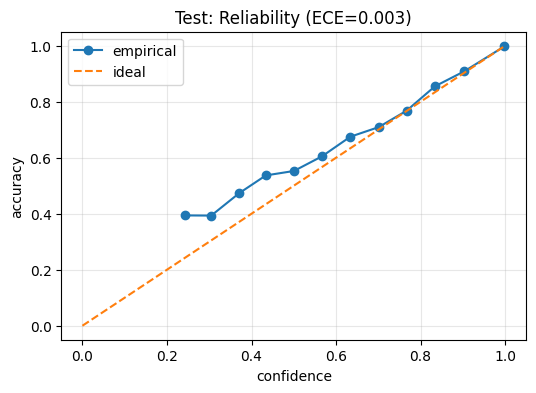

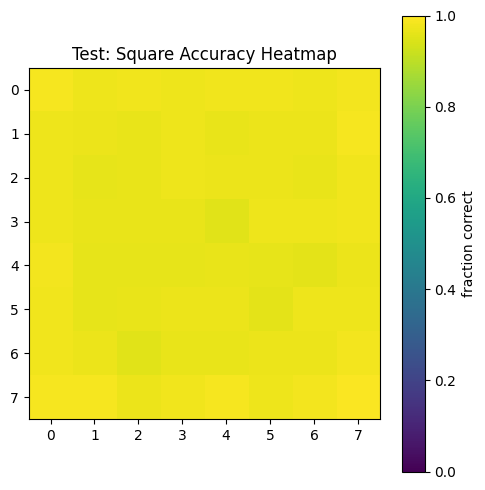

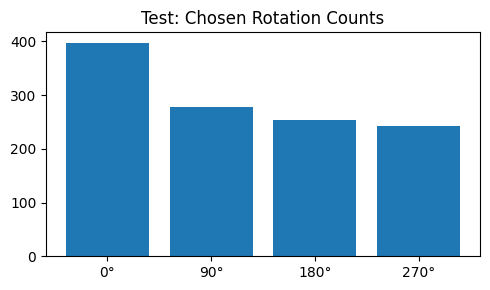

In [10]:
res = evaluate_plus(
    model,
    dataloader=test_loader,  # or val_loader
    device="cpu",
    empty_class_idx=12,
    id_to_piece=DEFAULT_ID_TO_PIECE,
    compute_plots=True,
    title_prefix="Test",
)

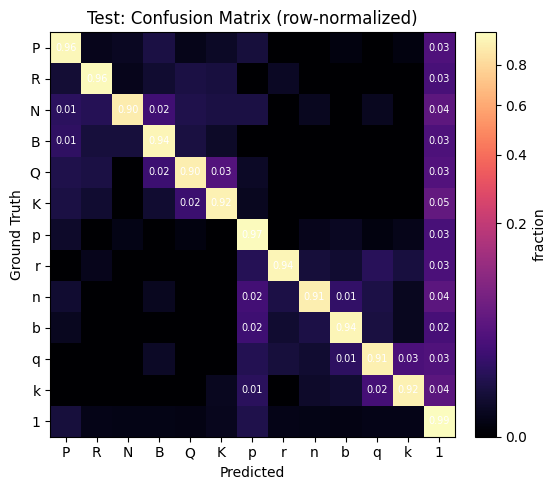

In [11]:
from matplotlib.colors import PowerNorm

cm = res["confusion_matrix"].astype(float)
labels = [DEFAULT_ID_TO_PIECE[i] for i in range(len(DEFAULT_ID_TO_PIECE))]

# Row-normalized (recall-style)
row_sums = cm.sum(axis=1, keepdims=True)
cm_row = np.divide(cm, np.maximum(row_sums, 1), where=row_sums > 0)

fig = plt.figure(figsize=(6, 5))
im = plt.imshow(cm_row, cmap="magma", norm=PowerNorm(gamma=0.4))  # boost low values
plt.title("Test: Confusion Matrix (row-normalized)")
plt.xlabel("Predicted")
plt.ylabel("Ground Truth")
plt.colorbar(im, fraction=0.046, pad=0.04, label="fraction")
plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)

# Annotate only reasonably large cells
for i in range(cm_row.shape[0]):
    for j in range(cm_row.shape[1]):
        v = cm_row[i, j]
        if v > 0.01:
            plt.text(
                j, i, f"{v:.2f}", va="center", ha="center", fontsize=7, color="white"
            )
plt.tight_layout()
plt.show()

Schlechtestes Bild Index: 624
Anzahl der Fehler: 34 / 64 Feldern
True FEN: RP4pr/1P4p1/B4n2/Q1Pp1bq1/1N1Ppbnk/R1N1Pp2/1BP3p1/KP3p1r
Pred FEN: 6P1/3PP3/6pp/1P2ppq1/1PQP1bqk/1BNPPpp1/1RBN2p1/RKP2ppk


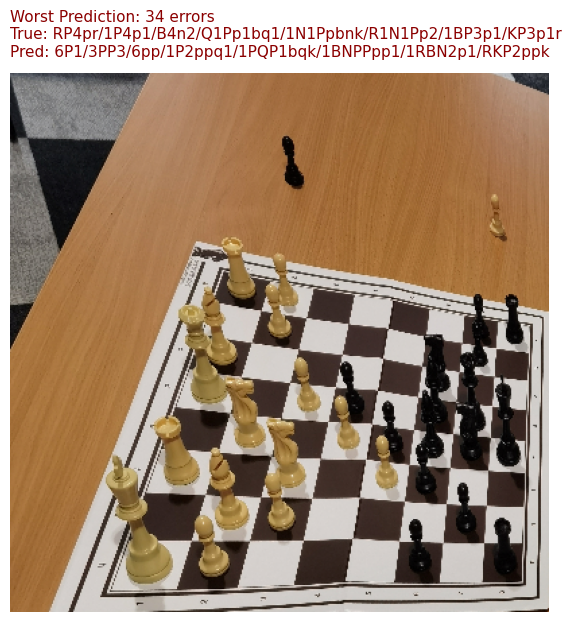

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

worst_idx = np.argmax(errors_per_board)
max_errors = errors_per_board[worst_idx]

print(f"Schlechtestes Bild Index: {worst_idx}")
print(f"Anzahl der Fehler: {max_errors} / 64 Feldern")
best_rot_indices = correct_suqares_per_rotation.argmax(axis=1)
best_rot = best_rot_indices[worst_idx]
true_board = all_labels[worst_idx, best_rot, :]
pred_board = all_preds[worst_idx]

idx_to_piece = {
    0: "P",
    1: "R",
    2: "N",
    3: "B",
    4: "Q",
    5: "K",
    6: "p",
    7: "r",
    8: "n",
    9: "b",
    10: "q",
    11: "k",
    12: "_",
}


def array_to_fen(board_array):
    fen_rows = []
    for row in range(8):
        row_str = ""
        empty_count = 0
        for col in range(8):
            piece_idx = board_array[row * 8 + col]
            piece_char = idx_to_piece.get(piece_idx, "?")

            if piece_char == "_":
                empty_count += 1
            else:
                if empty_count > 0:
                    row_str += str(empty_count)
                    empty_count = 0
                row_str += piece_char
        if empty_count > 0:
            row_str += str(empty_count)
        fen_rows.append(row_str)
    return "/".join(fen_rows)


true_fen = array_to_fen(true_board)
pred_fen = array_to_fen(pred_board)

print(f"True FEN: {true_fen}")
print(f"Pred FEN: {pred_fen}")

# 4. Zeige das Bild an
# Falls du den Pfad in der Loop gespeichert hast, können wir das Originalbild laden
try:
    worst_image_path = all_paths[worst_idx]
    img = mpimg.imread(worst_image_path)

    plt.figure(figsize=(7, 7))
    plt.imshow(img)
    plt.axis("off")

    title_text = (
        f"Worst Prediction: {max_errors} errors\nTrue: {true_fen}\nPred: {pred_fen}"
    )
    plt.title(title_text, fontsize=11, loc="left", pad=12, color="darkred")
    plt.show()
except IndexError:
    print(
        "\n[HINWEIS]: 'all_paths' scheint leer zu sein. Hast du in deiner Evaluationsschleife 'all_paths.extend(paths)' hinzugefügt?"
    )
except FileNotFoundError:
    print(
        f"\n[HINWEIS]: Konnte das Bild unter '{worst_image_path}' nicht laden (möglicherweise ein lokaler Pfadfehler)."
    )

In [16]:
worst_image_path

'G:/Meine Ablage/DLCV/Fine-Tuning/ed44bd07-d47c-4736-ba96-66dc721ef5dd.png'